**Image:** `ronak-valobobhai.jpg` — a woman standing in front of an open door

**Sub questions:**
- Convert the image to grayscale
- **(a)** Apply **Otsu thresholding** to obtain a binary mask for the foreground
  (woman and the room). Report the threshold value.
- **(b)** Apply **histogram equalization only to the foreground region**.
  Describe what hidden features are revealed.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Load colour image and convert to grayscale
img_bgr  = cv.imread('../images/ronak-valobobhai.jpg')
assert img_bgr is not None, "Could not load ronak-valobobhai.jpg"

img_rgb  = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

print(f"Colour image shape : {img_bgr.shape}")
print(f"Grayscale shape    : {img_gray.shape}")
print(f"Dtype              : {img_gray.dtype}")
print(f"Mean intensity     : {img_gray.mean():.2f}")
print(f"Std deviation      : {img_gray.std():.2f}")
print(f"Min / Max          : {img_gray.min()} / {img_gray.max()}")


Colour image shape : (5867, 4693, 3)
Grayscale shape    : (5867, 4693)
Dtype              : uint8
Mean intensity     : 27.63
Std deviation      : 55.16
Min / Max          : 0 / 255


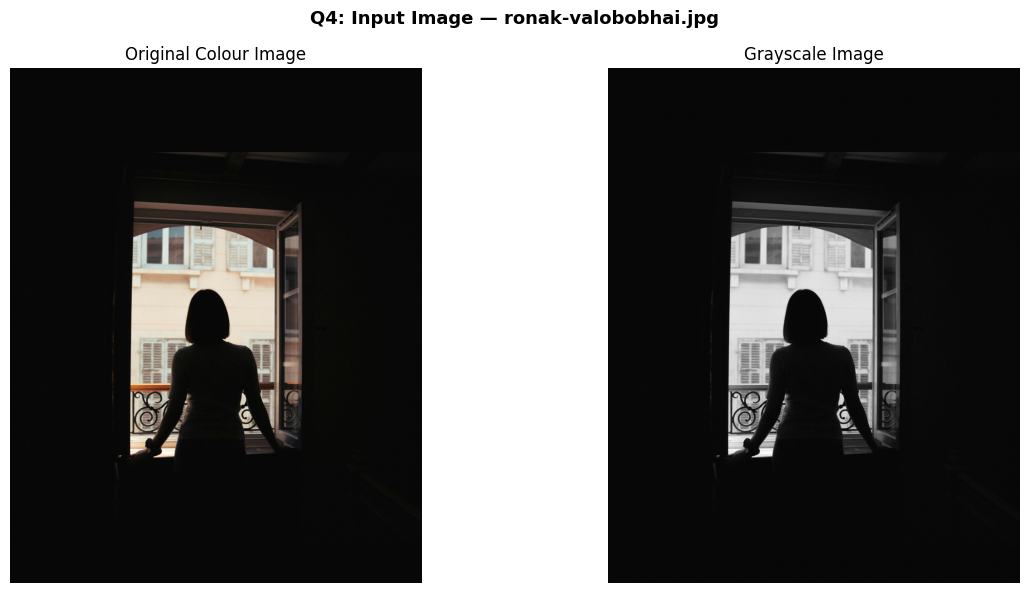

In [2]:
os.makedirs('../outputs/q4', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Colour Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Grayscale Image', fontsize=12)
axes[1].axis('off')

plt.suptitle('Q4: Input Image — ronak-valobobhai.jpg', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q4/q4_original_gray.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) Otsu Thresholding

In [3]:
# ── Apply Otsu thresholding ──────────────────────────────────────────────────
# cv.THRESH_BINARY + cv.THRESH_OTSU automatically finds the optimal threshold
otsu_thresh, binary_mask = cv.threshold(
    img_gray, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

print(f"Otsu threshold value : {int(otsu_thresh)}")
print()

# Analyse what the binary mask contains
fg_pixels = np.sum(binary_mask == 255)
bg_pixels = np.sum(binary_mask == 0)
total     = binary_mask.size

print(f"White pixels (above threshold) : {fg_pixels:,}  ({100*fg_pixels/total:.1f}%)")
print(f"Black pixels (below threshold) : {bg_pixels:,}  ({100*bg_pixels/total:.1f}%)")
print()
print("Note: pixels BELOW the Otsu threshold = dark region = woman + room = foreground")
print("      pixels ABOVE the Otsu threshold = bright region = window = background")


Otsu threshold value : 101

White pixels (above threshold) : 2,551,467  (9.3%)
Black pixels (below threshold) : 24,982,364  (90.7%)

Note: pixels BELOW the Otsu threshold = dark region = woman + room = foreground
      pixels ABOVE the Otsu threshold = bright region = window = background


In [4]:
# ── Build foreground mask ────────────────────────────────────────────────────
# The foreground (woman and the room) is the DARK region — pixels BELOW the threshold
# So used THRESH_BINARY_INV: pixels < threshold → 255 (foreground), rest → 0

_, foreground_mask = cv.threshold(
    img_gray, int(otsu_thresh), 255,
    cv.THRESH_BINARY_INV
)

# Verify mask covers the expected region
fg_count = np.sum(foreground_mask == 255)
total    = foreground_mask.size
print(f"Foreground mask covers : {fg_count:,} pixels ({100*fg_count/total:.1f}% of image)")


Foreground mask covers : 24,982,364 pixels (90.7% of image)


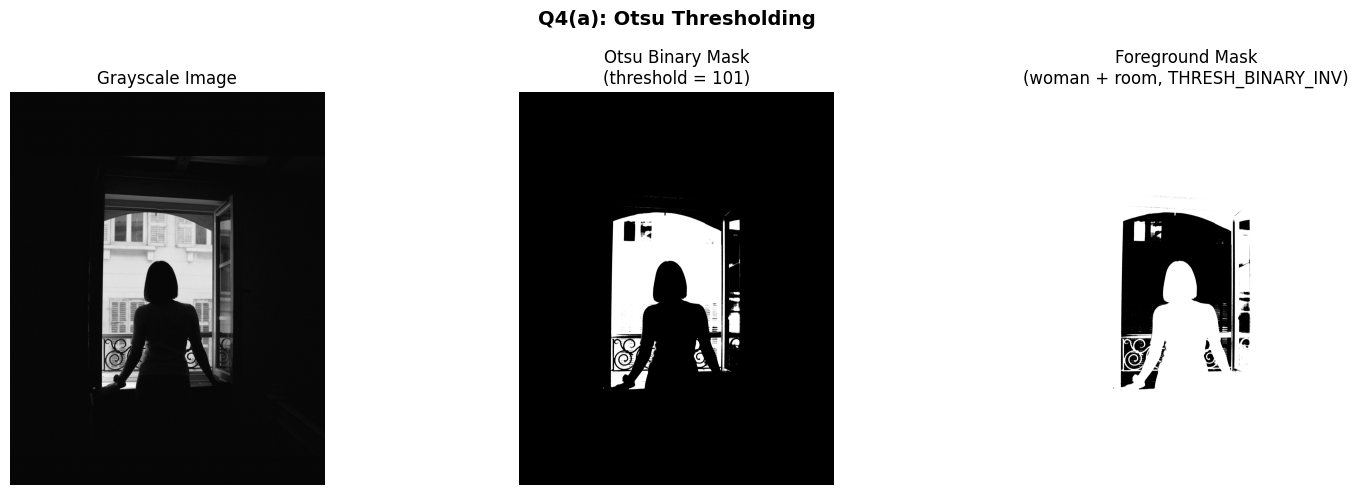

In [5]:
# ── Visualise: grayscale, Otsu binary, and foreground mask ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q4(a): Otsu Thresholding', fontsize=14, fontweight='bold')

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Otsu Binary Mask\n(threshold = {int(otsu_thresh)})', fontsize=12)
axes[1].axis('off')

axes[2].imshow(foreground_mask, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Foreground Mask\n(woman + room, THRESH_BINARY_INV)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q4/q4_otsu_masks.png', dpi=150, bbox_inches='tight')
plt.show()


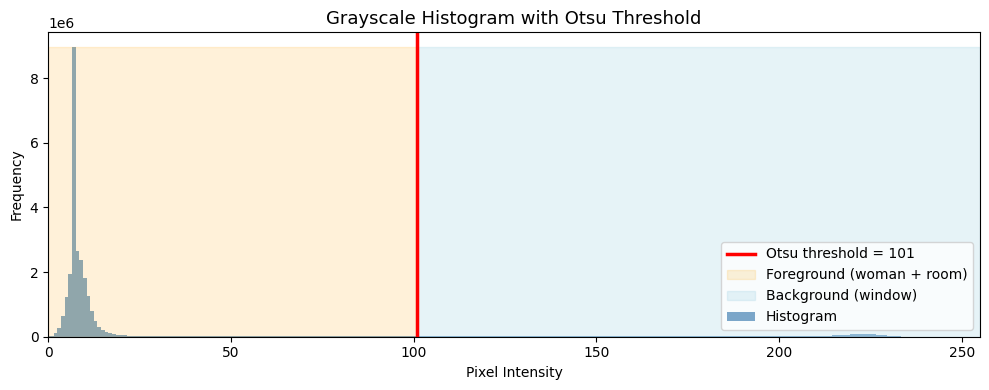

In [6]:
# ── Histogram with Otsu threshold line ──────────────────────────────────────
hist = np.histogram(img_gray.ravel(), bins=256, range=(0, 256))[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(256), hist, color='steelblue', alpha=0.7, width=1.0, label='Histogram')
ax.axvline(otsu_thresh, color='red', linewidth=2.5,
           label=f'Otsu threshold = {int(otsu_thresh)}')
ax.fill_betweenx([0, hist.max()], 0, otsu_thresh,
                 color='orange', alpha=0.15, label='Foreground (woman + room)')
ax.fill_betweenx([0, hist.max()], otsu_thresh, 255,
                 color='lightblue', alpha=0.3, label='Background (window)')
ax.set_title('Grayscale Histogram with Otsu Threshold', fontsize=13)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.set_xlim([0, 255])
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/q4/q4_otsu_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


## (b) Histogram Equalization — Foreground Only

In [7]:
# ── Custom histogram equalization function (reused from Q3) ─────────────────
def histogram_equalize(image):
    """Manual histogram equalization for a flat array of pixel values."""
    M_N = len(image)
    L   = 256
    hist = np.zeros(L, dtype=np.int64)
    for v in image:
        hist[v] += 1
    cdf = np.cumsum(hist)
    lut = np.round((L - 1) / M_N * cdf).astype(np.uint8)
    return lut[image]


# ── Apply HE only to foreground pixels ───────────────────────────────────────
# Step 1: Copy the grayscale image
result = img_gray.copy()

# Step 2: Extract foreground pixel values (where mask == 255)
fg_pixel_values = img_gray[foreground_mask == 255]
print(f"Number of foreground pixels : {len(fg_pixel_values):,}")

# Step 3: Equalize only those pixel values
fg_equalized = histogram_equalize(fg_pixel_values)

# Step 4: Place equalized values back into the result image
result[foreground_mask == 255] = fg_equalized

print("Selective histogram equalization applied to foreground only.")
print()
print(f"Foreground pixels — Before: mean={fg_pixel_values.mean():.2f}, std={fg_pixel_values.std():.2f}")
print(f"Foreground pixels — After : mean={fg_equalized.mean():.2f}, std={fg_equalized.std():.2f}")


Number of foreground pixels : 24,982,364
Selective histogram equalization applied to foreground only.

Foreground pixels — Before: mean=10.82, std=12.60
Foreground pixels — After : mean=149.05, std=65.95


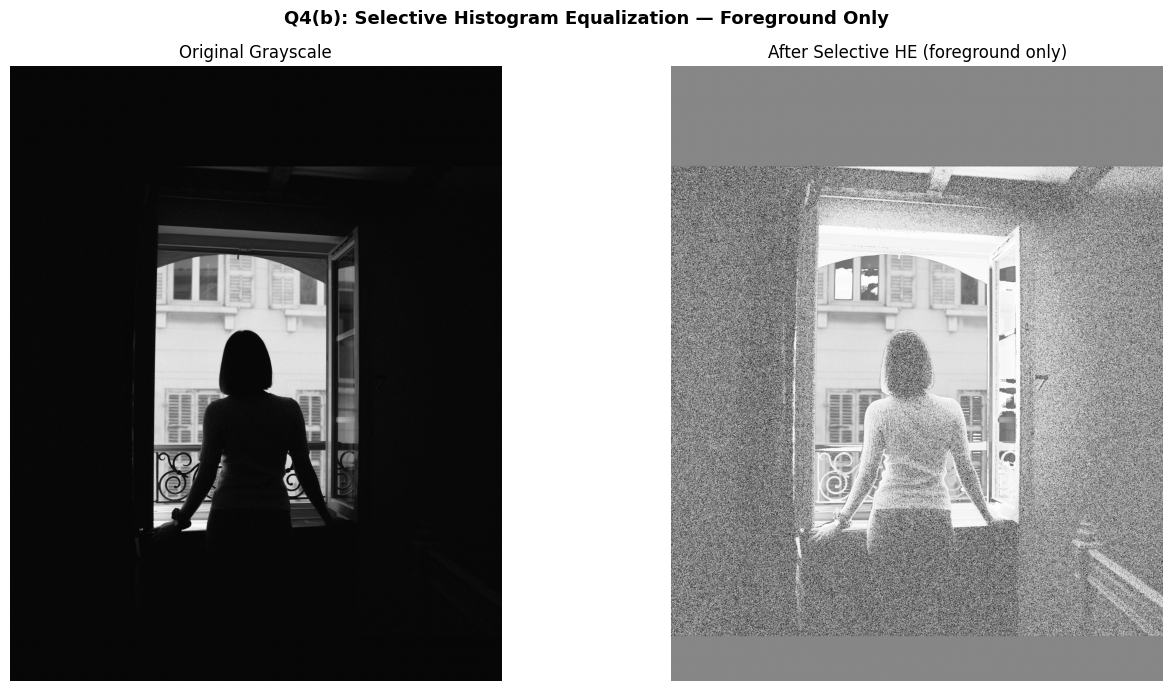

In [8]:
# ── Main results: original vs selective HE ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Q4(b): Selective Histogram Equalization — Foreground Only',
             fontsize=13, fontweight='bold')

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Grayscale', fontsize=12)
axes[0].axis('off')

axes[1].imshow(result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('After Selective HE (foreground only)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q4/q4_selective_he_result.png', dpi=150, bbox_inches='tight')
plt.show()


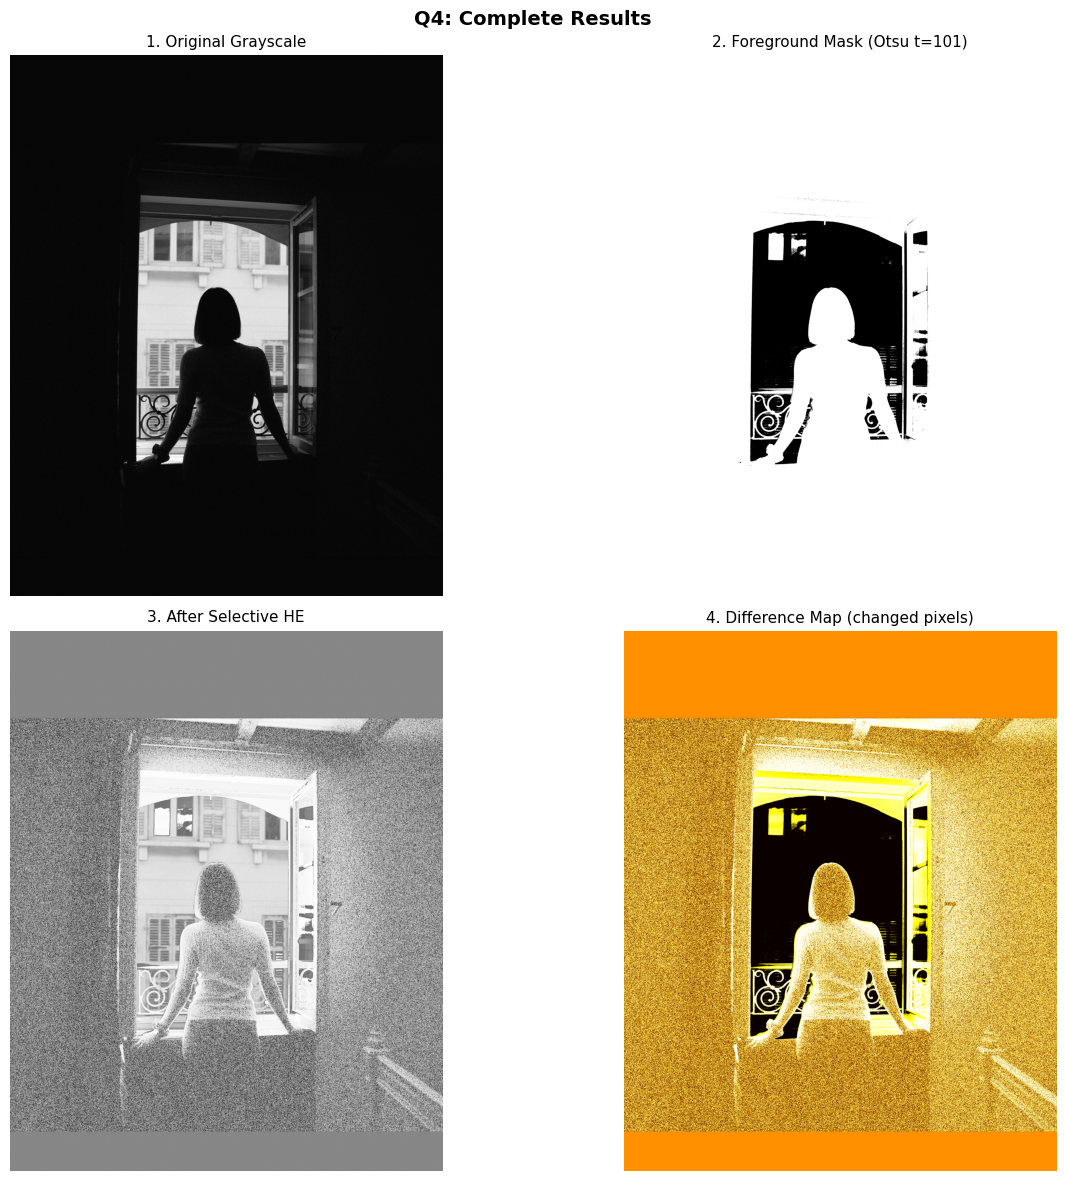

In [9]:
# ── 4-panel comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Q4: Complete Results', fontsize=14, fontweight='bold')

axes[0, 0].imshow(img_gray,        cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('1. Original Grayscale',   fontsize=11); axes[0, 0].axis('off')

axes[0, 1].imshow(foreground_mask, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'2. Foreground Mask (Otsu t={int(otsu_thresh)})', fontsize=11)
axes[0, 1].axis('off')

axes[1, 0].imshow(result,          cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('3. After Selective HE', fontsize=11); axes[1, 0].axis('off')

# Difference image to show what changed
diff = cv.absdiff(img_gray, result).astype(np.float32)
axes[1, 1].imshow(diff, cmap='hot')
axes[1, 1].set_title('4. Difference Map (changed pixels)', fontsize=11)
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q4/q4_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


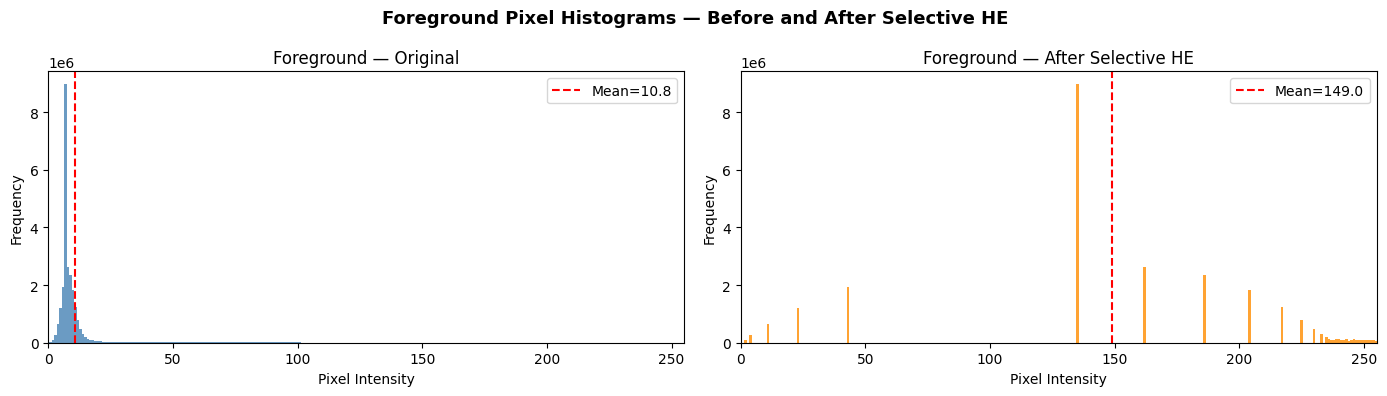

In [10]:
# ── Histogram of foreground region — before and after ────────────────────────
hist_fg_orig = np.histogram(fg_pixel_values, bins=256, range=(0,256))[0]
hist_fg_eq   = np.histogram(fg_equalized,    bins=256, range=(0,256))[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Foreground Pixel Histograms — Before and After Selective HE',
             fontsize=13, fontweight='bold')

axes[0].bar(range(256), hist_fg_orig, color='steelblue', alpha=0.8, width=1.0)
axes[0].set_title('Foreground — Original', fontsize=12)
axes[0].set_xlabel('Pixel Intensity'); axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 255])
axes[0].axvline(fg_pixel_values.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={fg_pixel_values.mean():.1f}')
axes[0].legend()

axes[1].bar(range(256), hist_fg_eq, color='darkorange', alpha=0.8, width=1.0)
axes[1].set_title('Foreground — After Selective HE', fontsize=12)
axes[1].set_xlabel('Pixel Intensity'); axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 255])
axes[1].axvline(fg_equalized.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={fg_equalized.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/q4/q4_fg_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
